In [1]:
import numpy as np
import scanpy as sc
from scib_metrics.benchmark import Benchmarker, BioConservation, BatchCorrection
import anndata as ad
%matplotlib inline

/home/dbj/anaconda3/envs/scib/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
adata=sc.read_h5ad('/home/dbj/SpaLP/gittest/SpaLP/general/cross-platform/Cross_platform_mouse_brain.h5ad')

In [3]:
adata.obsm["Unintegrated"] = adata.obsm["X_pca"]

In [4]:
adata

AnnData object with n_obs × n_vars = 140951 × 87
    obs: 'batch'
    uns: 'log1p', 'pca'
    obsm: '1slice_pretrain', '2slices_pretrain', 'BANKSY', 'NicheCompass', 'SpaLP', 'Unintegrated', 'X_pca', 'spatial'
    varm: 'PCs'

In [5]:
#Since lack ground truth label, we only calculate the batch effect.

bm = Benchmarker(adata,
                 batch_key="batch",
                 label_key='batch',
                 bio_conservation_metrics=None,
                 batch_correction_metrics=BatchCorrection(bras=False,kbet_per_label=False),
                 embedding_obsm_keys=["BANKSY","NicheCompass","SpaLP","1slice_pretrain","2slices_pretrain"],
                 pre_integrated_embedding_obsm_key="Unintegrated",
                 n_jobs=-1)

Metrics:   0%|                                                                                                                                                     | 0/5 [00:00<?, ?it/s, Batch correction: ilisi_knn]WARNING:2026-03-11 14:53:59,903:jax._src.xla_bridge:794: An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.

Metrics:  20%|██████████████████████████▍                                                                                                         | 1/5 [00:00<00:03,  1.02it/s, Batch correction: graph_connectivity]/home/dbj/anaconda3/envs/scib/lib/python3.10/site-packages/scib_metrics/metrics/_graph_connectivity.py:32: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(comps)

Embeddings:  20%|█████████████████████████████████▍                                                                                

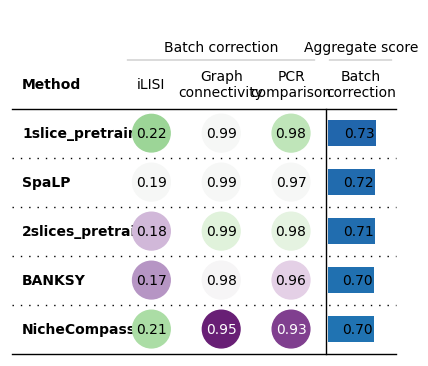

In [6]:
bm.benchmark()# pipeline

bm.plot_results_table(min_max_scale=False)

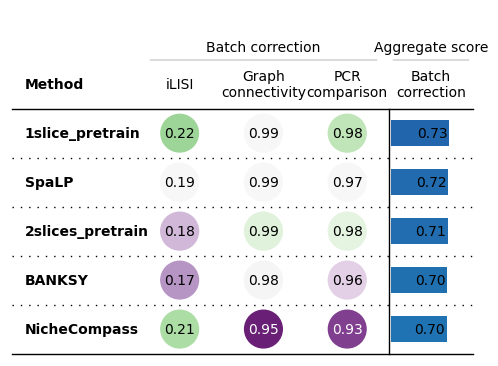

In [12]:
import matplotlib.pyplot as plt
tab = bm.plot_results_table(show=False)
fig = plt.gcf() 
fig.set_size_inches(6, 4.5) 
fig.savefig("/home/dbj/SpaLP/gittest/SpaLP/general/cross-platform/high_res_benchmark.png", bbox_inches="tight", dpi=500)
plt.show()

In [39]:
adata=sc.read_h5ad('/home/dbj/SpaLP/gittest/SpaLP/general/MERFISH/SCIB_MERFISH76_77_78.h5ad')

In [40]:
adata.obsm["Unintegrated"] = adata.obsm["X_pca"]

In [41]:
adata

AnnData object with n_obs × n_vars = 132215 × 1122
    obs: 'donor_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'disease_ontology_term_id', 'tissue_ontology_term_id', 'cell_type_ontology_term_id', 'assay_ontology_term_id', 'suspension_type', 'cluster_id_transfer', 'subclass_transfer', 'cluster_confidence_score', 'subclass_confidence_score', 'high_quality_transfer', 'major_brain_region', 'ccf_region_name', 'brain_section_label', 'tissue_type', 'is_primary_data', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'slice'
    uns: 'log1p', 'pca'
    obsm: '1slice_pretrain', '2slices_pretrain', 'BANKSY', 'NicheCompass', 'SpaLP', 'Unintegrated', 'X_CCF', 'X_pca', 'X_spatial_coords', 'X_umap', 'spatial'
    varm: 'PCs'

In [46]:
bm = Benchmarker(adata,
                 batch_key="slice",
                 label_key='major_brain_region',
                 bio_conservation_metrics=None,
                 batch_correction_metrics=BatchCorrection(),
                 embedding_obsm_keys=["BANKSY","NicheCompass","SpaLP","1slice_pretrain","2slices_pretrain"],
                 pre_integrated_embedding_obsm_key="Unintegrated",
                 n_jobs=-1)

Metrics:  60%|███████████████████████████████████████████████████████████████████████████████▏                                                    | 3/5 [01:24<01:10, 35.10s/it, Batch correction: graph_connectivity]/home/dbj/anaconda3/envs/scib/lib/python3.10/site-packages/scib_metrics/metrics/_graph_connectivity.py:32: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(comps)

Embeddings:  20%|█████████████████████████████████▍                                                                                                                                     | 1/5 [01:25<05:43, 85.79s/it]
                                                                                                                                                                                                                      
Metrics:  60%|██████████████████████████████████████████████████████████████████████

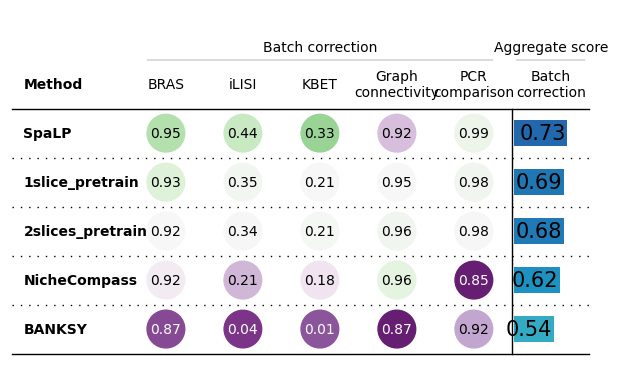

In [47]:
bm.benchmark()# pipeline

bm.plot_results_table(min_max_scale=False)

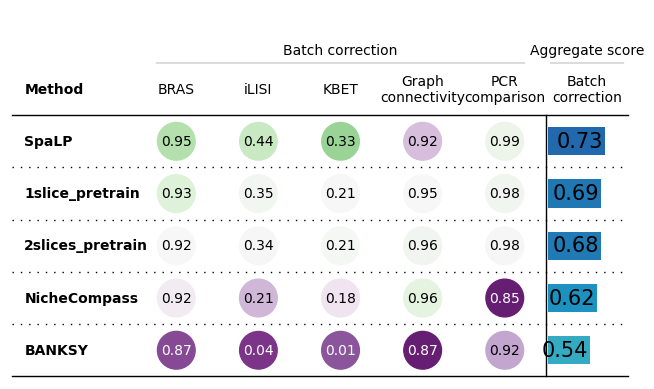

In [51]:
import matplotlib.pyplot as plt
tab = bm.plot_results_table(show=False)
fig = plt.gcf() 
fig.set_size_inches(8, 4.8) 
fig.savefig("/home/dbj/SpaLP/gittest/SpaLP/general/MERFISH/high_res_benchmark.png", bbox_inches="tight", dpi=500)
plt.show()